In [37]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA


In [2]:
mental_health = pd.read_csv("../Teen_Mental_Health_Dataset.csv")
mental_health.head(5)

mental_health.info()
# ? No nulls in the base
mental_health.describe()
# ? General view of the base
mental_health.shape
# ? 1200 x 13
mental_health.dtypes
# ? Everything with the data types = OK

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [3]:
# Creating auxilary columns
mental_health["usage_group"] = pd.cut(
    mental_health["daily_social_media_hours"],
    bins=[0, 2, 4, 6, 24],
    labels=["low", "moderate", "high", "very_high"]
)
mental_health["usage_group"].value_counts()

print(mental_health.groupby("usage_group", observed=True)["anxiety_level"].mean())


mental_health["sleep_group"] = pd.cut(
    mental_health["sleep_hours"],
    bins=[0, 4, 6, 10],
    labels=["very low", "low", "normal"]
)

print(mental_health.groupby("sleep_group", observed=True)["anxiety_level"].mean())


mental_health["screen_time_before_sleep_group"] = pd.cut(
    mental_health["screen_time_before_sleep"],
    bins=[0, 1, 4],
    labels=["low", "high"],
    include_lowest=True
)

print(mental_health.groupby("screen_time_before_sleep_group", observed=True)["anxiety_level"].mean())




usage_group
low          5.284884
moderate     5.735955
high         5.770833
very_high    5.577381
Name: anxiety_level, dtype: float64
sleep_group
very low    5.400000
low         5.710794
normal      5.587983
Name: anxiety_level, dtype: float64
screen_time_before_sleep_group
low     5.688462
high    5.622340
Name: anxiety_level, dtype: float64


In [4]:
numeric_cols = [
    "daily_social_media_hours",
    "screen_time_before_sleep",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
    "academic_performance",
    "physical_activity",
]

mental_health[numeric_cols].describe()

,daily_social_media_hours,screen_time_before_sleep,sleep_hours,stress_level,anxiety_level,academic_performance,physical_activity
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.536667,1.740333,6.449417,5.445833,5.636667,2.990383,1.014500
std,2.029599,0.716660,1.442677,2.903290,2.859453,0.576758,0.582185
min,1.000000,0.500000,4.000000,1.000000,1.000000,2.000000,0.000000
25%,2.800000,1.100000,5.200000,3.000000,3.000000,2.500000,0.500000
50%,4.500000,1.800000,6.500000,5.000000,6.000000,2.990000,1.000000
75%,6.300000,2.400000,7.600000,8.000000,8.000000,3.480000,1.500000
max,8.000000,3.000000,9.000000,10.000000,10.000000,4.000000,2.000000


## Analysis of discret and continuos numbers on the data frame
##### Comparating different types of variables from the df with visualization from matplotlib

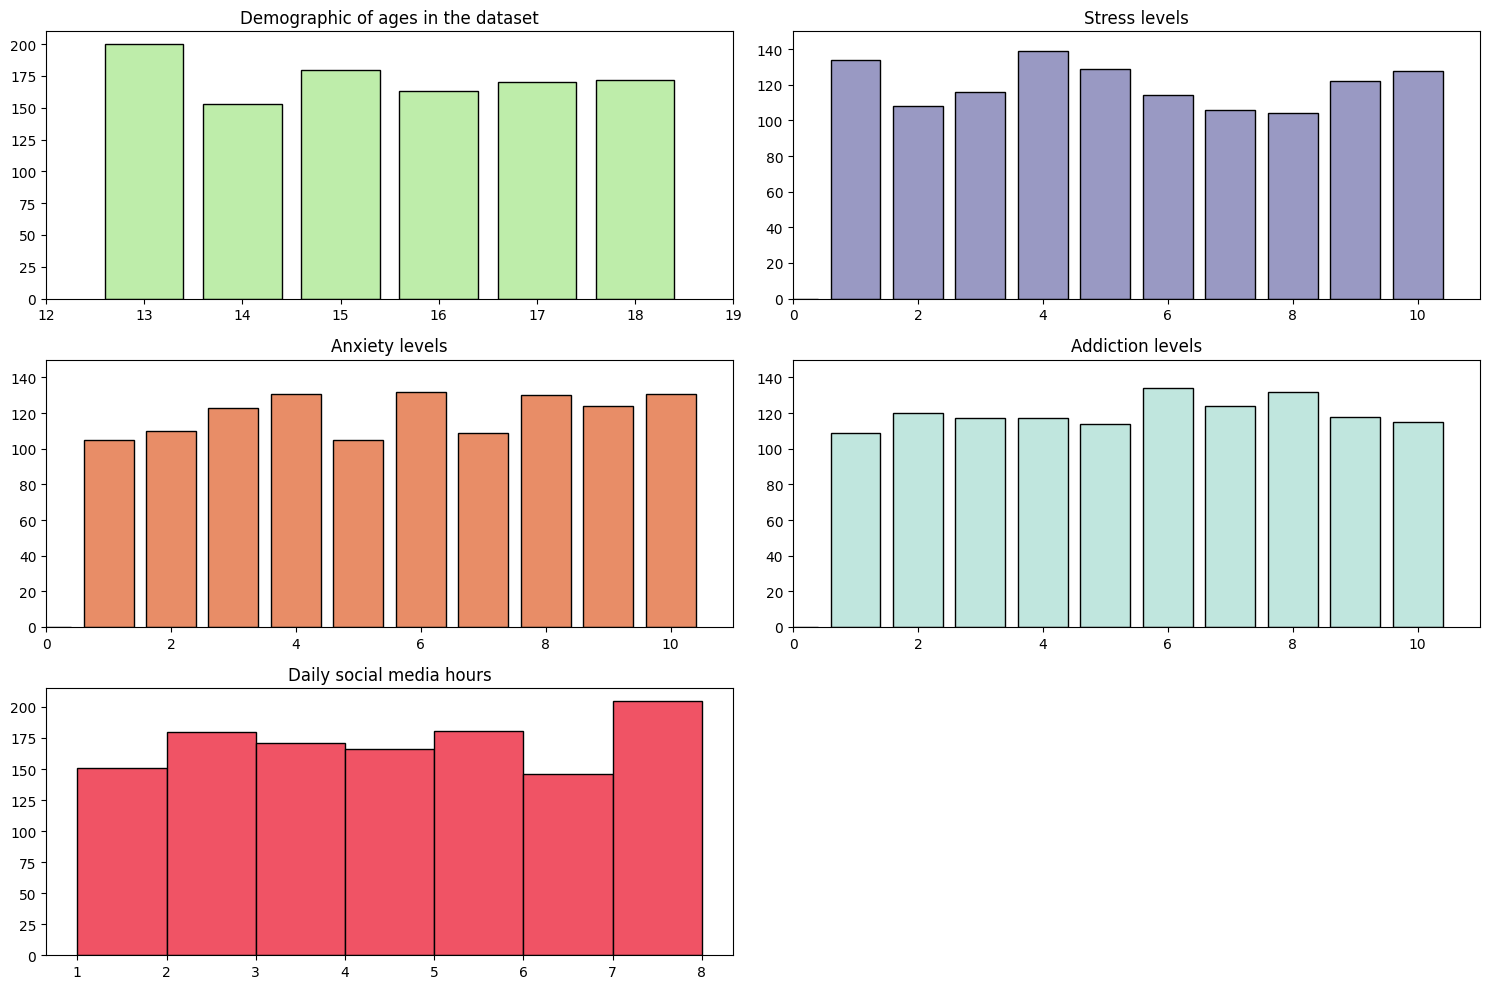

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# Demographic of ages of the users in the data base
age_counter = Counter(mental_health["age"])
xs = range(13, 19)
ys = [age_counter[x] for x in xs]
color = "#BEEDAA"

axes[0, 0].bar(xs, ys, color=color, edgecolor="black")
axes[0, 0].axis([12, 19, 0, 210])
axes[0, 0].set_title("Demographic of ages in the dataset")

# Stress levels
stress_level_counter = Counter(mental_health["stress_level"])
xs = range(0, 11)
ys = [stress_level_counter[x] for x in xs]

axes[0, 1].bar(xs, ys, color="#9999C3", edgecolor="black")
axes[0, 1].axis([0, 11, 0, 150])
axes[0, 1].set_title("Stress levels")

# Anxiety levels
anxiety_level_counter = Counter(mental_health["anxiety_level"])
xs = range(0, 11)
ys = [anxiety_level_counter[x] for x in xs]

axes[1, 0].bar(xs, ys, color="#E88D67", edgecolor="black")
axes[1, 0].axis([0, 11, 0, 150])
axes[1, 0].set_title("Anxiety levels")

# Addiction levels
addiction_level_counter = Counter(mental_health["addiction_level"])
xs = range(0, 11)
ys = [addiction_level_counter[x] for x in xs]

axes[1, 1].bar(xs, ys, color="#C0E6DE", edgecolor="black")
axes[1, 1].axis([0, 11, 0, 150])
axes[1, 1].set_title("Addiction levels")

# Daily social media hours
axes[2, 0].hist(
    mental_health["daily_social_media_hours"],
    color="#F05365",
    edgecolor="black",
    bins=7
)
axes[2, 0].set_title("Daily social media hours")

# Hide the empty subplot
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()


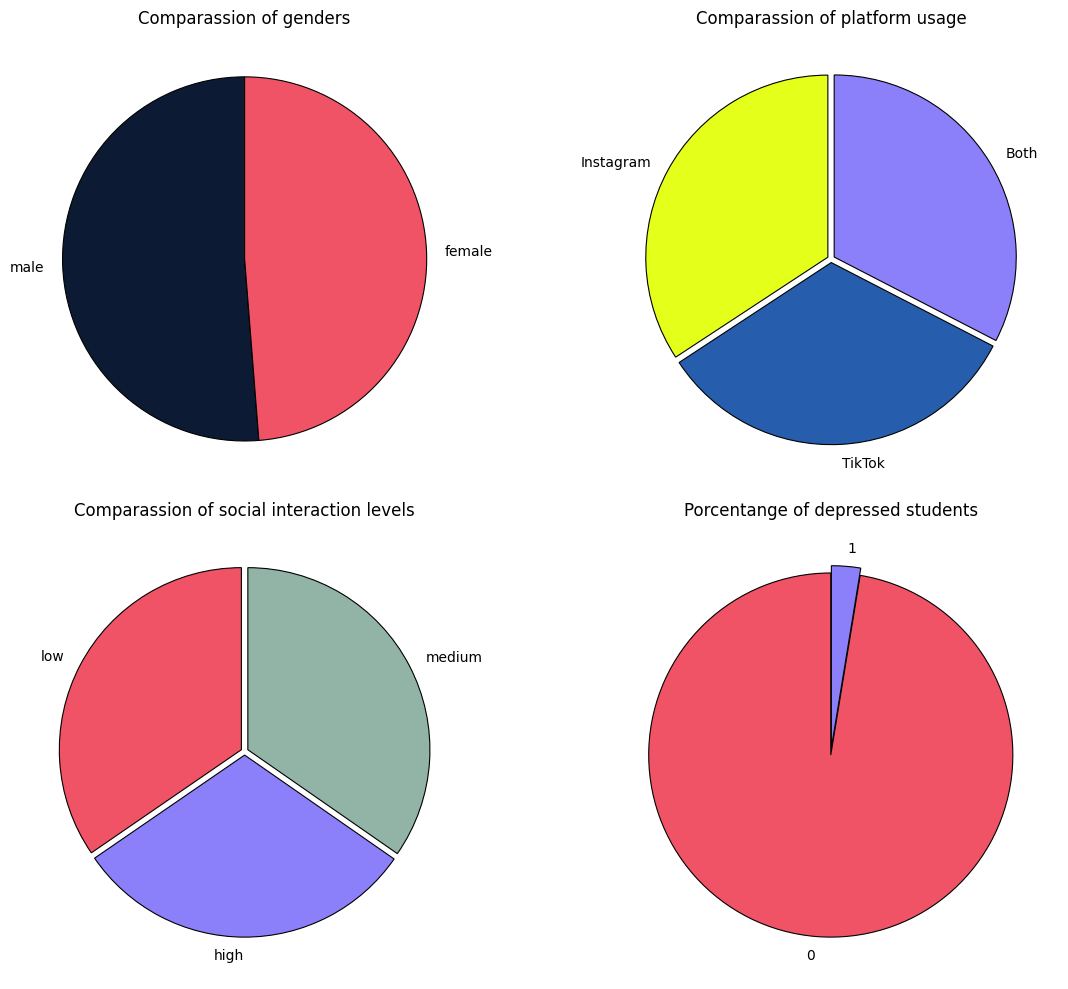

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Comparing genders
gender_count = Counter(mental_health["gender"])
labels = list(gender_count.keys())
values = list(gender_count.values())
colors = ["#0C1B33", "#F05365"]

axes[0, 0].set_title("Comparassion of genders")
axes[0, 0].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

# Comparing platform usage
platform_usage_count = Counter(mental_health["platform_usage"])
labels = list(platform_usage_count.keys())
values = list(platform_usage_count.values())
colors = ["#E4FF1A", "#275DAD", "#8B80F9"]
explode = [0.02, 0.02, 0.02]

axes[0, 1].set_title("Comparassion of platform usage")
axes[0, 1].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

# Social interaction level
social_interaction_level_counter = Counter(mental_health["social_interaction_level"])
labels = list(social_interaction_level_counter.keys())
values = list(social_interaction_level_counter.values())
colors = ["#F05365", "#8B80F9", "#92B4A7"]
explode = [0.02, 0.02, 0.02]

axes[1, 0].set_title("Comparassion of social interaction levels")
axes[1, 0].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

# Depression label
depression_label_counter = Counter(mental_health["depression_label"])
labels = list(depression_label_counter.keys())
values = list(depression_label_counter.values())
colors = ["#F05365", "#8B80F9"]
explode = [0.02, 0.02]

axes[1, 1].set_title("Porcentange of depressed students")
axes[1, 1].pie(
    values,
    labels=labels,
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

plt.tight_layout()
plt.show()


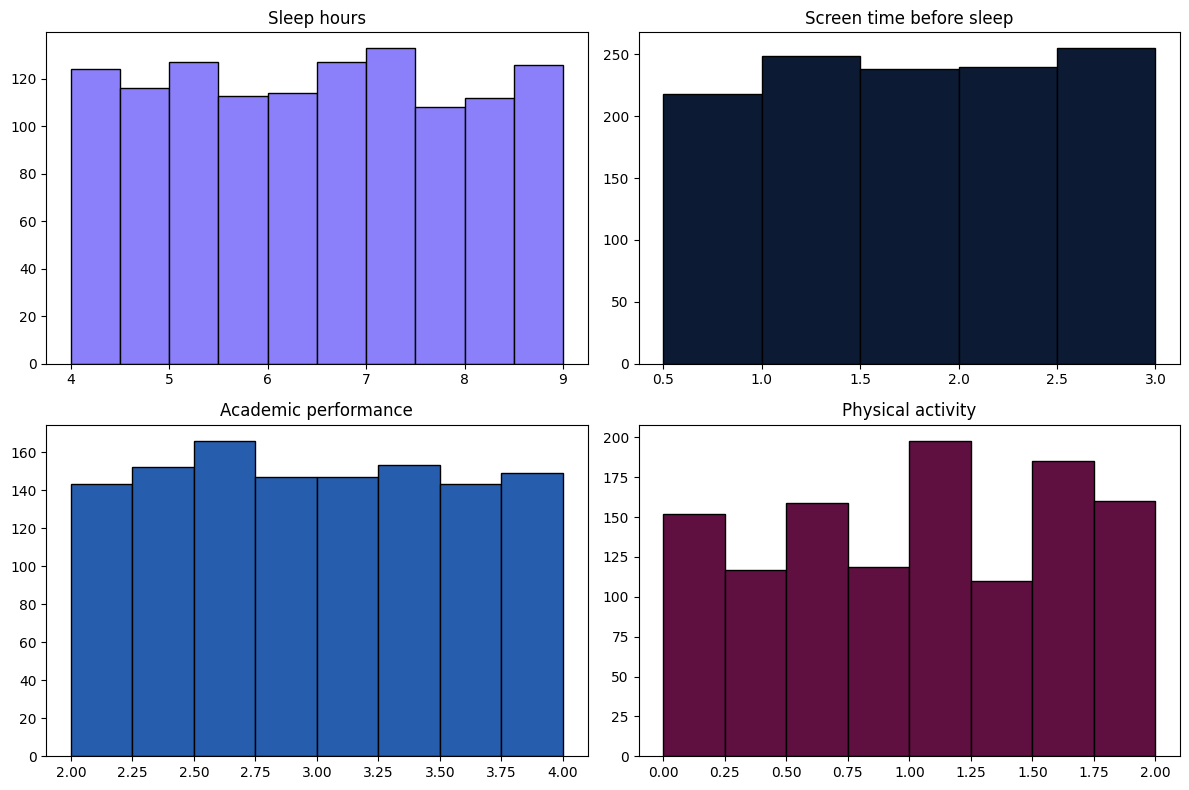

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sleep hours
axes[0, 0].hist(
    mental_health["sleep_hours"],
    color="#8B80F9",
    edgecolor="black",
    bins=10
)
axes[0, 0].set_title("Sleep hours")

# Screen time before sleep
axes[0, 1].hist(
    mental_health["screen_time_before_sleep"],
    color="#0C1B33",
    edgecolor="black",
    bins=5
)
axes[0, 1].set_title("Screen time before sleep")

# Academic performance
axes[1, 0].hist(
    mental_health["academic_performance"],
    color="#275DAD",
    edgecolor="black",
    bins=8
)
axes[1, 0].set_title("Academic performance")

# Physical activity
axes[1, 1].hist(
    mental_health["physical_activity"],
    color="#5F0F40",
    edgecolor="black",
    bins=8
)
axes[1, 1].set_title("Physical activity")

plt.tight_layout()
plt.show()


# Checking correlation between variables

In [8]:
corr_columns = [
        "daily_social_media_hours",
        "screen_time_before_sleep",
        "sleep_hours",
        "stress_level",
        "depression_label",
        "anxiety_level",
        "academic_performance",
        "physical_activity",
]


mental_health[corr_columns].corr()

,daily_social_media_hours,screen_time_before_sleep,sleep_hours,stress_level,depression_label,anxiety_level,academic_performance,physical_activity
daily_social_media_hours,1.000000,0.035777,-0.009472,0.030698,0.175201,0.027835,0.013179,0.025546
screen_time_before_sleep,0.035777,1.000000,0.010235,-0.008650,-0.016502,-0.010344,-0.034715,-0.026450
sleep_hours,-0.009472,0.010235,1.000000,-0.010979,-0.190630,-0.011879,0.021866,0.012701
stress_level,0.030698,-0.008650,-0.010979,1.000000,0.170474,0.015811,-0.000600,0.012159
depression_label,0.175201,-0.016502,-0.190630,0.170474,1.000000,0.169566,0.001441,-0.017598
anxiety_level,0.027835,-0.010344,-0.011879,0.015811,0.169566,1.000000,-0.064379,-0.022233
academic_performance,0.013179,-0.034715,0.021866,-0.000600,0.001441,-0.064379,1.000000,0.023312
physical_activity,0.025546,-0.026450,0.012701,0.012159,-0.017598,-0.022233,0.023312,1.000000


# Checking the correlations by different types of groups
##### (age_group, adictiviness_group and others). 

In [9]:


mental_health["age_group"] =pd.cut(
    mental_health["age"],
    bins=[12, 15, 18], # Starts with 13 and ends with 18
    labels=["13-15","16-18"]
)

for age_group, group_df in mental_health.groupby("age_group"):
    print(f"\nAge group: {age_group}")
    print(group_df[corr_columns].corr())


Age group: 13-15
                          daily_social_media_hours  screen_time_before_sleep  \
daily_social_media_hours                  1.000000                  0.055517   
screen_time_before_sleep                  0.055517                  1.000000   
sleep_hours                              -0.059811                 -0.006175   
stress_level                              0.049313                  0.008496   
depression_label                          0.189863                 -0.006168   
anxiety_level                            -0.018251                  0.002871   
academic_performance                     -0.007781                 -0.056528   
physical_activity                        -0.008732                  0.054356   

                          sleep_hours  stress_level  depression_label  \
daily_social_media_hours    -0.059811      0.049313          0.189863   
screen_time_before_sleep    -0.006175      0.008496         -0.006168   
sleep_hours                  1.000000     

C:\Users\leona\AppData\Local\Temp\ipykernel_25608\854310910.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age_group, group_df in mental_health.groupby("age_group"):


In [10]:
mental_health.groupby("usage_group")[
    ["anxiety_level", "stress_level", "depression_label"]
].mean()

C:\Users\leona\AppData\Local\Temp\ipykernel_25608\578364907.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mental_health.groupby("usage_group")[


,anxiety_level,stress_level,depression_label
usage_group,,,
low,5.284884,5.610465,0.000000
moderate,5.735955,5.264045,0.000000
high,5.770833,5.235119,0.026786
very_high,5.577381,5.764881,0.065476


In [11]:
print(mental_health.groupby("usage_group", observed=False)["depression_label"].agg(["count", "sum", "mean"]))
print(mental_health.groupby("usage_group", observed=False)[["anxiety_level", "stress_level"]].mean())
print(mental_health.groupby("usage_group", observed=False)[["anxiety_level", "stress_level"]].median())


             count  sum      mean
usage_group                      
low            172    0  0.000000
moderate       356    0  0.000000
high           336    9  0.026786
very_high      336   22  0.065476
             anxiety_level  stress_level
usage_group                             
low               5.284884      5.610465
moderate          5.735955      5.264045
high              5.770833      5.235119
very_high         5.577381      5.764881
             anxiety_level  stress_level
usage_group                             
low                    5.0           5.0
moderate               6.0           5.0
high                   6.0           5.0
very_high              5.0           6.0


In [12]:
pd.crosstab(mental_health["usage_group"], mental_health["depression_label"])

depression_label,0,1
usage_group,,
low,172,0
moderate,356,0
high,327,9
very_high,314,22


# Searching for outliers

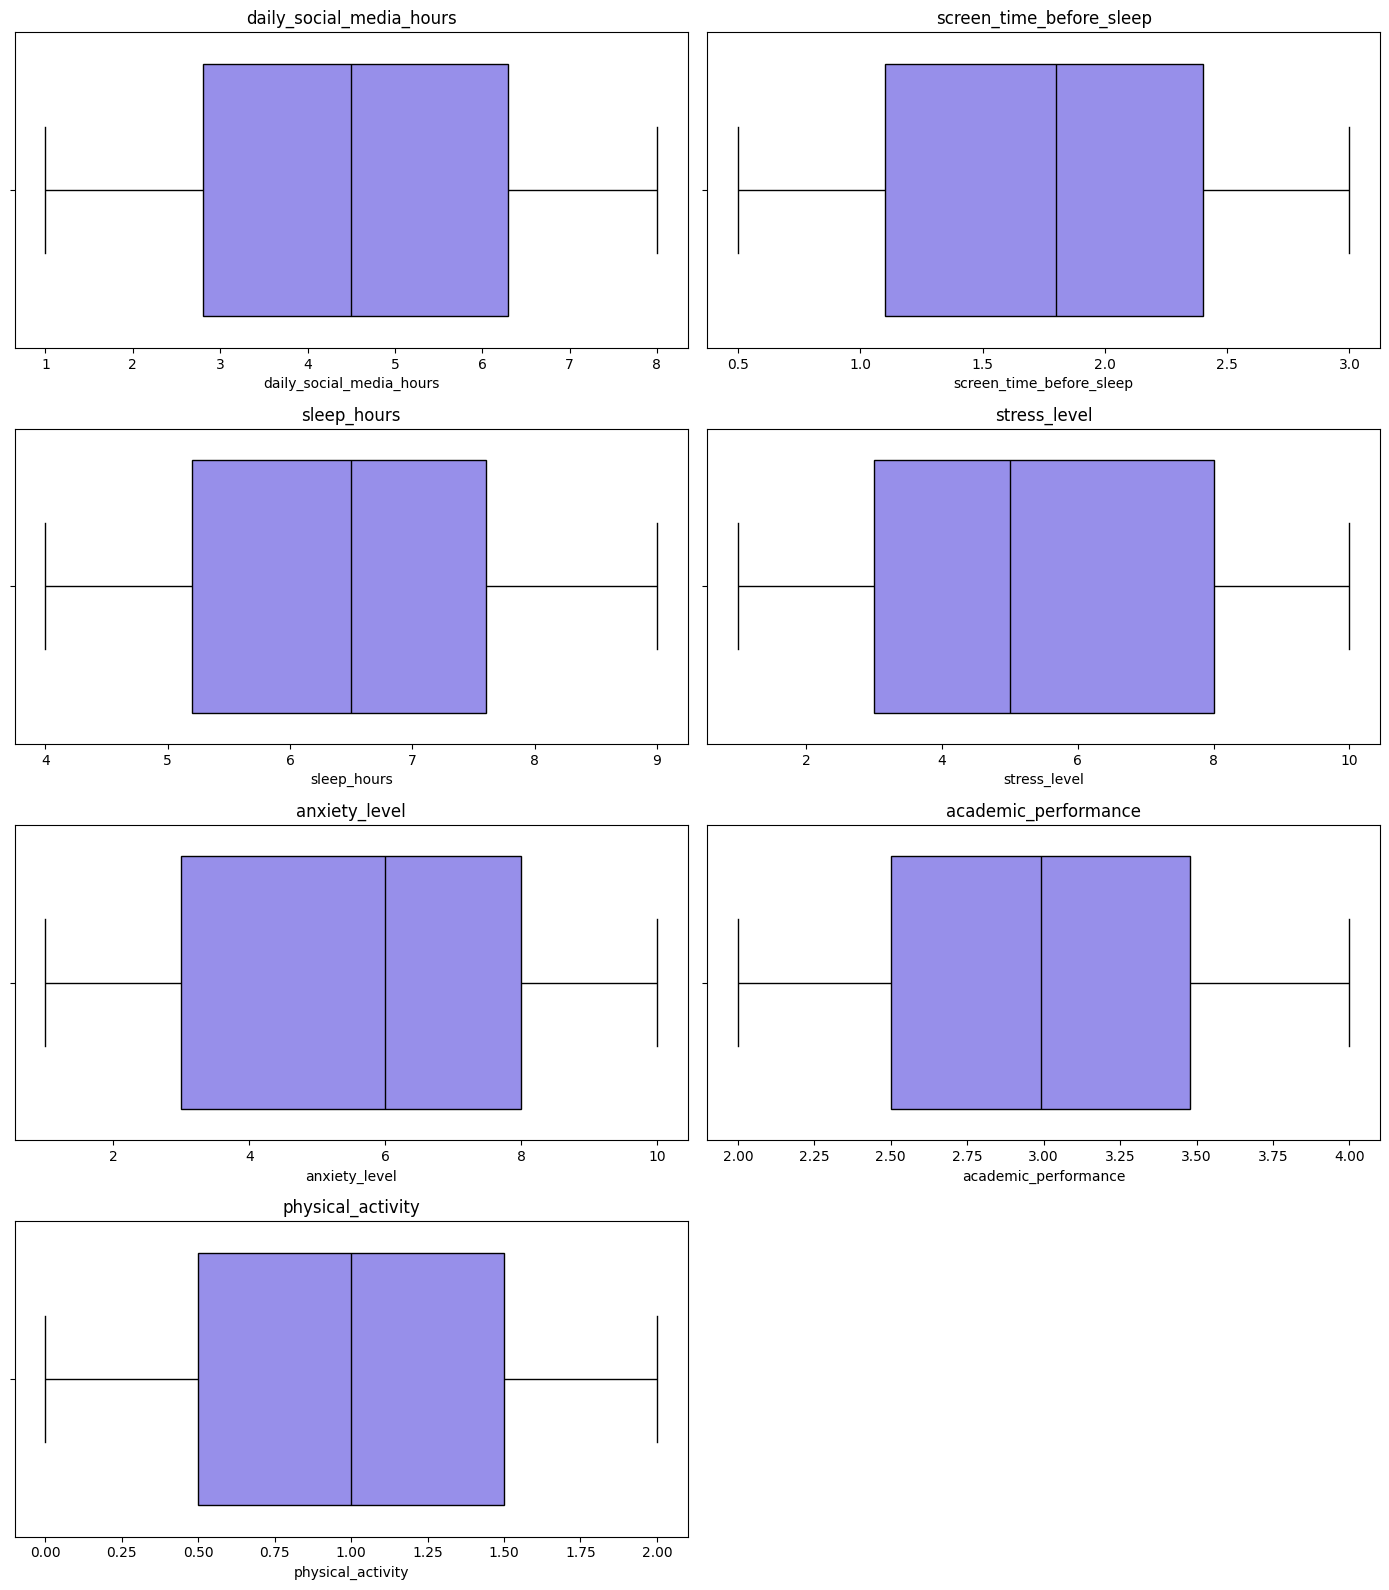

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=mental_health[col], ax=axes[i], color="#8B80F9", linecolor="#000000")
    axes[i].set_title(col)

# Hide any extra empty subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


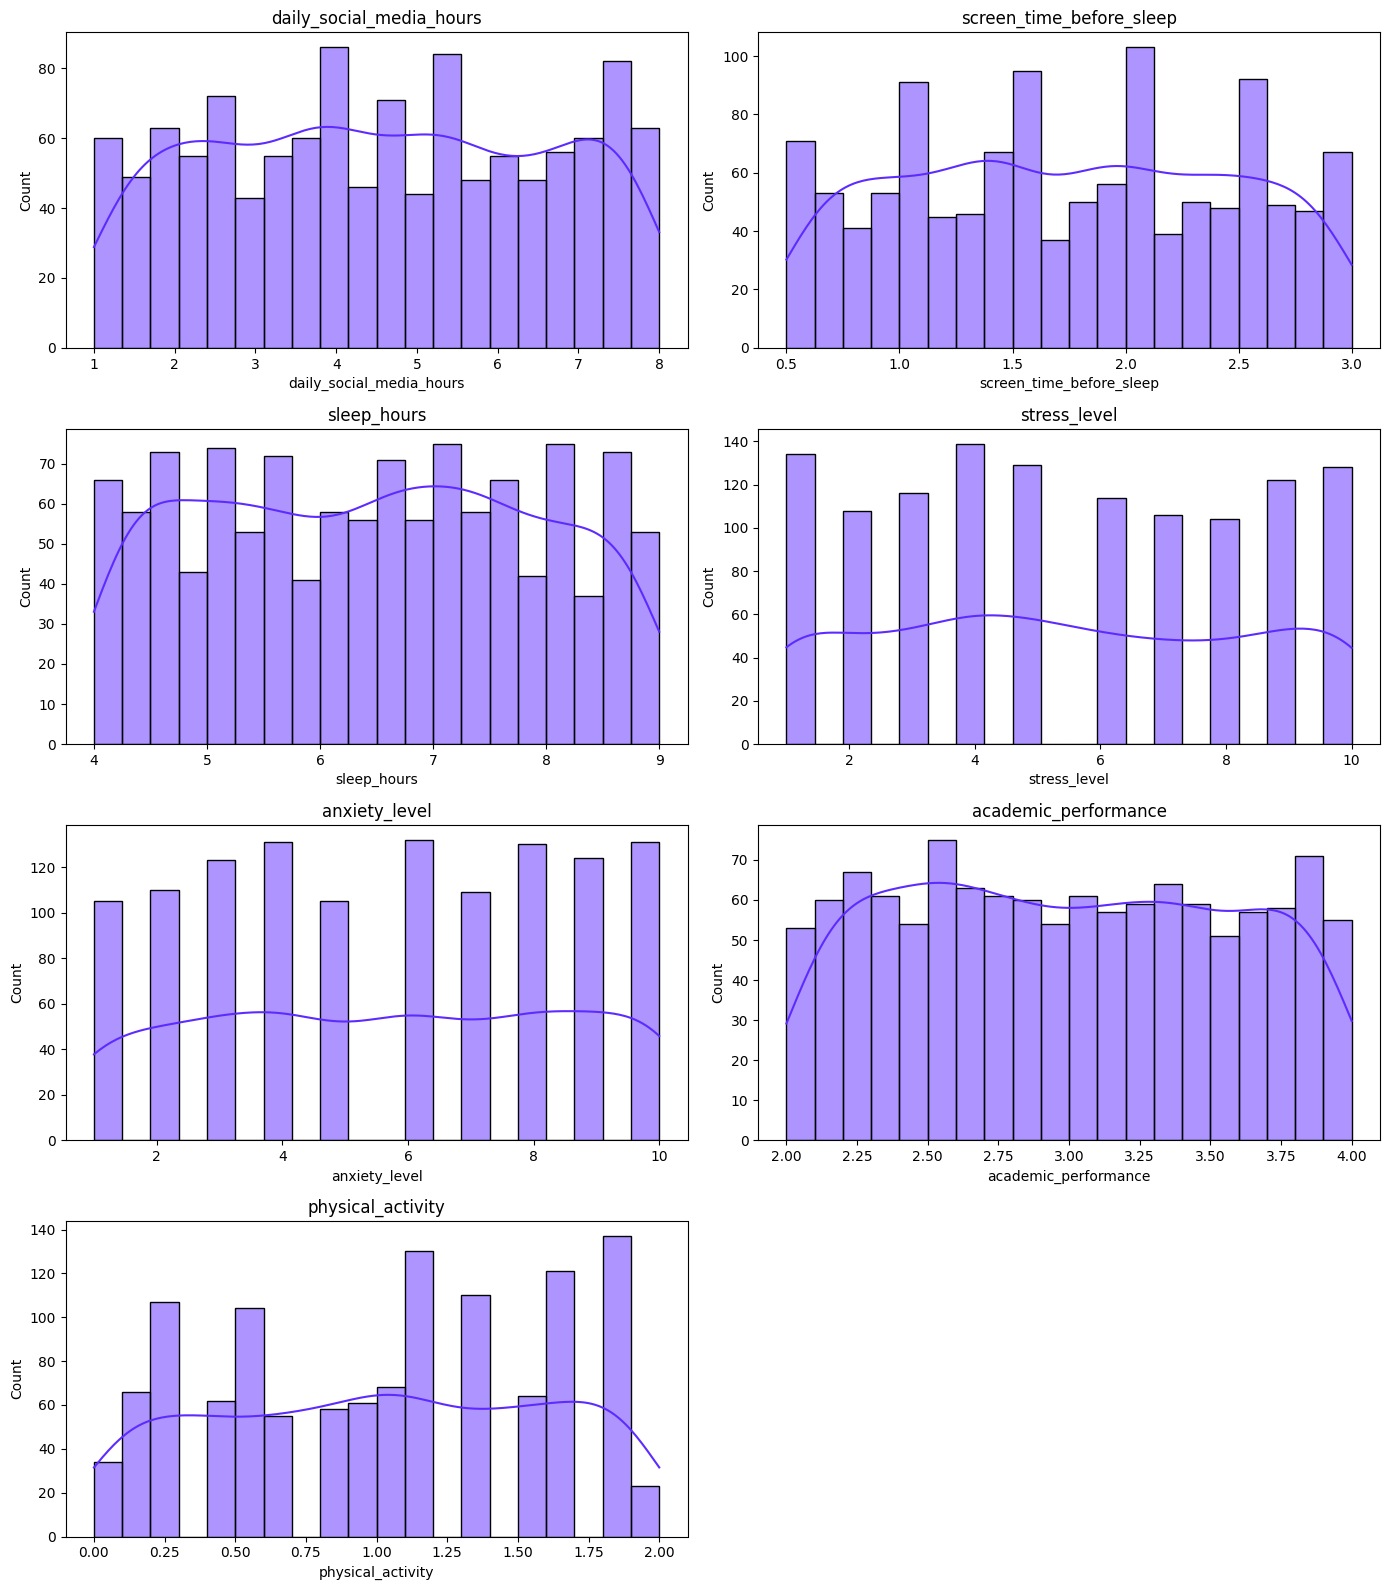

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        mental_health[col],
        bins=20,
        kde=True,
        ax=axes[i],
        color="#5E2BFF"
    )
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


# Comparing if the social media addicteds have a healthy lifestyle.

In [15]:
# Seeing if the social media addicted do more or less physical activity.

# Getting every type of group
types_of_usage_group = list(mental_health["usage_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["usage_group"] == group, "physical_activity"].mean())



very_high
1.0538690476190478
low
1.0040697674418604
high
0.987797619047619
moderate
1.0075842696629214


In [16]:
# Seeing if the social media addicted do physical activity.

# Getting every type of group
types_of_usage_group = list(mental_health["usage_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["usage_group"] == group, "physical_activity"].mean())



very_high
1.0538690476190478
low
1.0040697674418604
high
0.987797619047619
moderate
1.0075842696629214


In [17]:
# Seeing if the social media addicted do sleep well

# Getting every type of group
types_of_usage_group = list(mental_health["sleep_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["sleep_group"] == group, "screen_time_before_sleep"].mean())


normal
1.7397711015736765
low
1.744399185336049
very low
1.58


In [18]:
# Seeing if the social media addicted do sleep well.

# Getting every type of group
types_of_usage_group = list(mental_health["screen_time_before_sleep_group"].unique())

# Putting them in a loop
for group in types_of_usage_group:
    # And then printing the mean
    print(group)
    print(mental_health.loc[mental_health["screen_time_before_sleep_group"] == group, "sleep_hours"].mean())


high
6.467872340425532
low
6.382692307692308


# Comparing different platforms

In [19]:
# Testing the different types of platforms

print(mental_health.groupby("platform_usage")["depression_label"].mean())
print(mental_health.groupby("platform_usage")["addiction_level"].mean())
print(mental_health.groupby("platform_usage")["anxiety_level"].mean())
print(mental_health.groupby("platform_usage")["stress_level"].mean())

platform_usage
Both         0.023018
Instagram    0.024331
TikTok       0.030151
Name: depression_label, dtype: float64
platform_usage
Both         5.496164
Instagram    5.581509
TikTok       5.615578
Name: addiction_level, dtype: float64
platform_usage
Both         5.488491
Instagram    5.669100
TikTok       5.748744
Name: anxiety_level, dtype: float64
platform_usage
Both         5.549872
Instagram    5.498783
TikTok       5.288945
Name: stress_level, dtype: float64


# Cleaning and padronizing the data

In [20]:
all_columns = mental_health.columns.to_list()

mental_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   age                             1200 non-null   int64   
 1   gender                          1200 non-null   object  
 2   daily_social_media_hours        1200 non-null   float64 
 3   platform_usage                  1200 non-null   object  
 4   sleep_hours                     1200 non-null   float64 
 5   screen_time_before_sleep        1200 non-null   float64 
 6   academic_performance            1200 non-null   float64 
 7   physical_activity               1200 non-null   float64 
 8   social_interaction_level        1200 non-null   object  
 9   stress_level                    1200 non-null   int64   
 10  anxiety_level                   1200 non-null   int64   
 11  addiction_level                 1200 non-null   int64   
 12  depression_label    

In [21]:
print(all_columns)
print(mental_health["social_interaction_level"].unique())

['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'usage_group', 'sleep_group', 'screen_time_before_sleep_group', 'age_group']
['low' 'high' 'medium']


In [22]:
# Selecting features

features_to_keep = [
    "age",
    "daily_social_media_hours",
    "sleep_hours",
    "screen_time_before_sleep",
    "academic_performance",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level"
]


features_to_dummy = [
#    "gender",
#    "platform_usage"
]


features_to_ordinal = [
    "social_interaction_level"
]


features_to_remove = [
    "depression_label",
    "usage_group",
    "sleep_group",
    "screen_time_before_sleep_group",
    "age_group"
]


In [23]:
selected_features = features_to_keep + features_to_ordinal
clean_df = mental_health[selected_features].copy()

In [24]:
print(clean_df["social_interaction_level"].dtype)
print(clean_df["social_interaction_level"].unique())

object
['low' 'high' 'medium']


In [25]:
# Encoding the features
## Encoding using ordinal encoder
encoder = OrdinalEncoder(categories=[["low", "medium", "high"]])

encoded_social_interaction_level = encoder.fit_transform(
    clean_df[["social_interaction_level"]].astype(str)
)

## Putting the encoded data to the original column
clean_df["social_interaction_level"] = encoded_social_interaction_level[:, 0]

print(clean_df["social_interaction_level"].unique())




[0. 2. 1.]


In [26]:
if features_to_dummy:
    dummies = pd.get_dummies(clean_df[features_to_dummy], dtype=int)
    clean_df = pd.concat([dummies, clean_df], axis=1)
    clean_df = clean_df.drop(columns=features_to_dummy)

print(clean_df.head())
print(clean_df.dtypes)



   age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0   14                       7.9          7.4                       2.9   
1   19                       1.9          8.0                       2.9   
2   17                       1.3          7.6                       0.5   
3   15                       7.4          6.9                       1.6   
4   15                       4.7          4.9                       3.0   

   academic_performance  physical_activity  stress_level  anxiety_level  \
0                  3.01                1.5             2              2   
1                  3.22                0.8             8              1   
2                  3.92                0.0             2              4   
3                  3.48                0.8             1              7   
4                  2.37                1.4             3              5   

   addiction_level  social_interaction_level  
0                1                       0.0  
1   

In [27]:
# Padronizing the data
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(clean_df)

scaled_df = pd.DataFrame(
    scaled_array,
    columns=clean_df.columns,
    index=clean_df.index
)

In [28]:
clean_df.columns.to_list()

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'social_interaction_level']

In [29]:
scaled_df.head(5)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,social_interaction_level
0,0.166667,0.985714,0.68,0.96,0.505,0.75,0.111111,0.111111,0.000000,0.0
1,1.000000,0.128571,0.80,0.96,0.610,0.40,0.777778,0.000000,1.000000,1.0
2,0.666667,0.042857,0.72,0.00,0.960,0.00,0.111111,0.333333,0.111111,1.0
3,0.333333,0.914286,0.58,0.44,0.740,0.40,0.000000,0.666667,0.888889,0.5
4,0.333333,0.528571,0.18,1.00,0.185,0.70,0.222222,0.444444,0.111111,0.5


# Kmean clustering

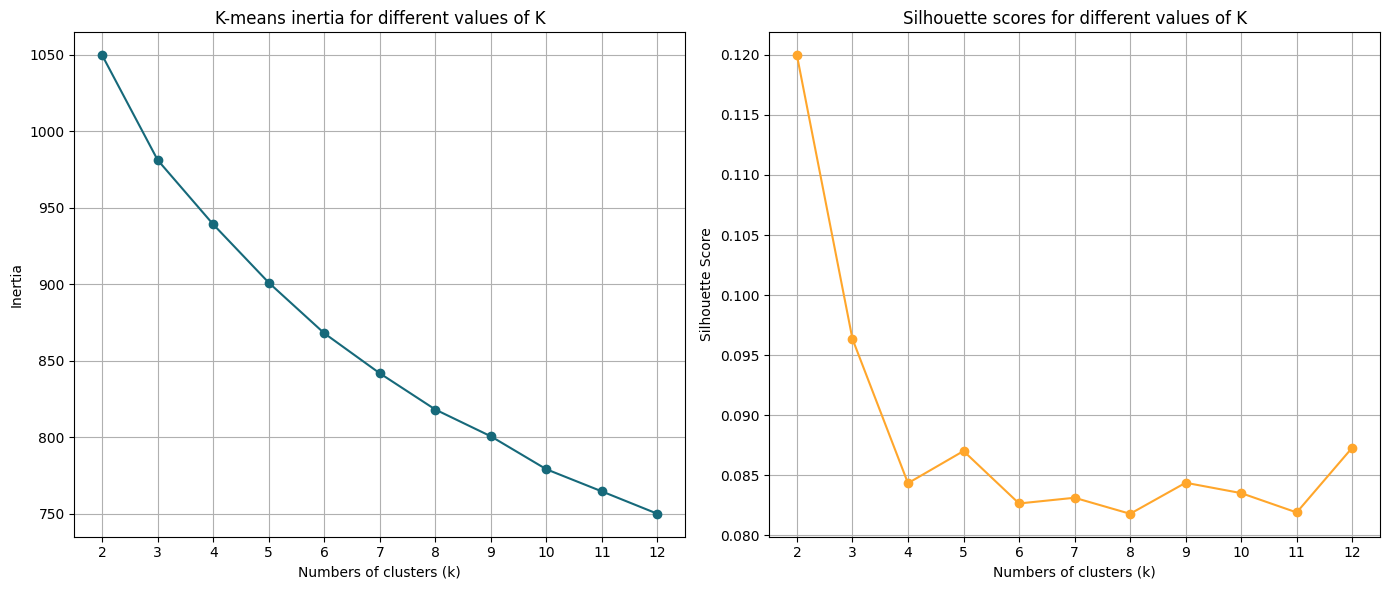

In [30]:
# Using the elbow and silhouette methods to get the optimal number of clusteres.

max_k = 12

inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init=20)

    cluster_labels = kmeans.fit_predict(scaled_df)

    sil_score = silhouette_score(scaled_df, cluster_labels)

    silhouette_scores.append(sil_score)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o', color="#16697A")
plt.title("K-means inertia for different values of K")
plt.xlabel("Numbers of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color="#FFA62B")
plt.title("Silhouette scores for different values of K")
plt.xlabel("Numbers of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()


In [31]:
final_k = 5

kmeans = KMeans(n_clusters=final_k, random_state=42, max_iter=1000, n_init=20)
cluster_labels = kmeans.fit_predict(scaled_df)

clustered_df = clean_df.copy()
clustered_df["Cluster"] = cluster_labels

clustered_df



,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,social_interaction_level,Cluster
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0.0,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,2.0,1
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,2.0,1
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1.0,4
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,3,4,4,0.0,2
1196,16,2.3,8.0,1.9,2.12,0.4,7,4,4,2.0,1
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,1,2.0,1
1198,15,3.9,8.5,2.1,3.19,0.6,7,9,9,2.0,3


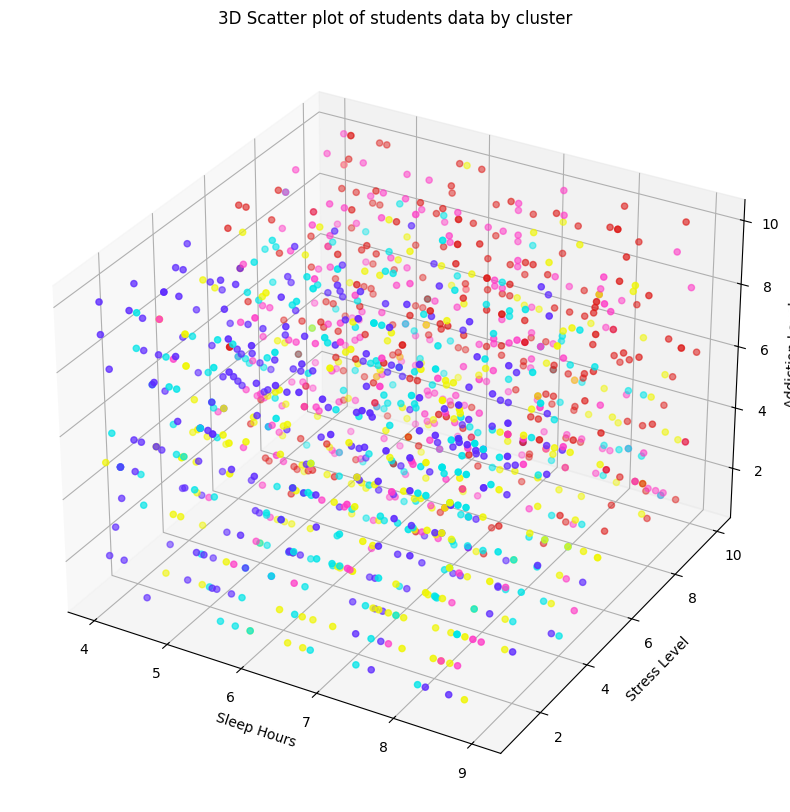

In [32]:
cluster_colors = {0 : "#FF3CC7",
                  1 : "#F0F600",
                  2 : "#00E5E8",
                  3 : "#DD1C1A",
                  4 : "#5E2BFF"
}

colors = clustered_df["Cluster"].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    clustered_df["sleep_hours"],
    clustered_df["stress_level"],
    clustered_df["addiction_level"],
    c=colors,
    marker="o"
)

ax.set_xlabel("Sleep Hours")
ax.set_ylabel("Stress Level")
ax.set_zlabel("Addiction Level")

ax.set_title("3D Scatter plot of students data by cluster")

plt.show()

In [33]:
clean_df.columns.to_list()

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'social_interaction_level']

In [34]:
# PCA

features = [
        'age', 'daily_social_media_hours', 'sleep_hours', 
        'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level',
        'anxiety_level', 'addiction_level', 'social_interaction_level'
]

clean_df

pca = PCA(n_components=3)
X_pca = pca.fit_transform(scaled_df)


In [35]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.16414458 0.11791977 0.10607591]
0.38814026364331494


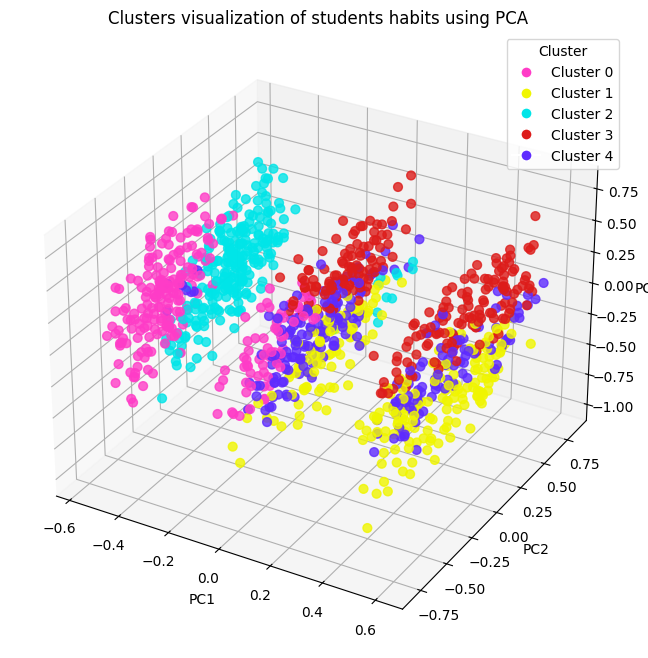

In [39]:
cluster_colors = {
    0: "#FF3CC7",
    1: "#F0F600",
    2: "#00E5E8",
    3: "#DD1C1A",
    4: "#5E2BFF"
}

colors = [cluster_colors[label] for label in cluster_labels]

final_k = 5

kmeans = KMeans(n_clusters=final_k, random_state=42, max_iter=1000, n_init=20)
cluster_labels = kmeans.fit_predict(scaled_df)

# PCA for performance
pca = PCA(n_components=3)
X_pca = pca.fit_transform(scaled_df)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=colors,
    s=40,
    alpha=0.8
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("Clusters visualization of students habits using PCA")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=f"Cluster {cluster}",
        markerfacecolor=color,
        markersize=8
    )
    for cluster, color in cluster_colors.items()
]

ax.legend(
    handles=legend_elements,
    title="Cluster",
    loc="upper right"
)

plt.show()


In [40]:
cluster_profile = clustered_df.groupby("Cluster").mean().round(2)
cluster_profile

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,social_interaction_level
Cluster,,,,,,,,,,
0,14.00,4.92,6.27,1.72,2.96,0.95,6.98,4.75,5.37,0.27
1,16.47,4.32,6.66,1.83,3.14,1.05,4.79,2.63,4.81,1.63
2,17.51,4.39,6.59,1.75,3.02,1.04,4.36,5.83,5.43,0.05
3,16.76,4.61,6.50,1.73,2.85,1.04,8.03,7.37,6.05,1.54
4,14.94,4.44,6.24,1.67,2.99,0.99,3.08,7.50,6.14,1.35


In [41]:
profile_columns = [
    "daily_social_media_hours",
    "screen_time_before_sleep",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
    "addiction_level",
    "academic_performance",
    "physical_activity",
    "social_interaction_level"
]

cluster_profile = clustered_df.groupby("Cluster")[profile_columns].mean().round(2)
cluster_profile

,daily_social_media_hours,screen_time_before_sleep,sleep_hours,stress_level,anxiety_level,addiction_level,academic_performance,physical_activity,social_interaction_level
Cluster,,,,,,,,,
0,4.92,1.72,6.27,6.98,4.75,5.37,2.96,0.95,0.27
1,4.32,1.83,6.66,4.79,2.63,4.81,3.14,1.05,1.63
2,4.39,1.75,6.59,4.36,5.83,5.43,3.02,1.04,0.05
3,4.61,1.73,6.50,8.03,7.37,6.05,2.85,1.04,1.54
4,4.44,1.67,6.24,3.08,7.50,6.14,2.99,0.99,1.35


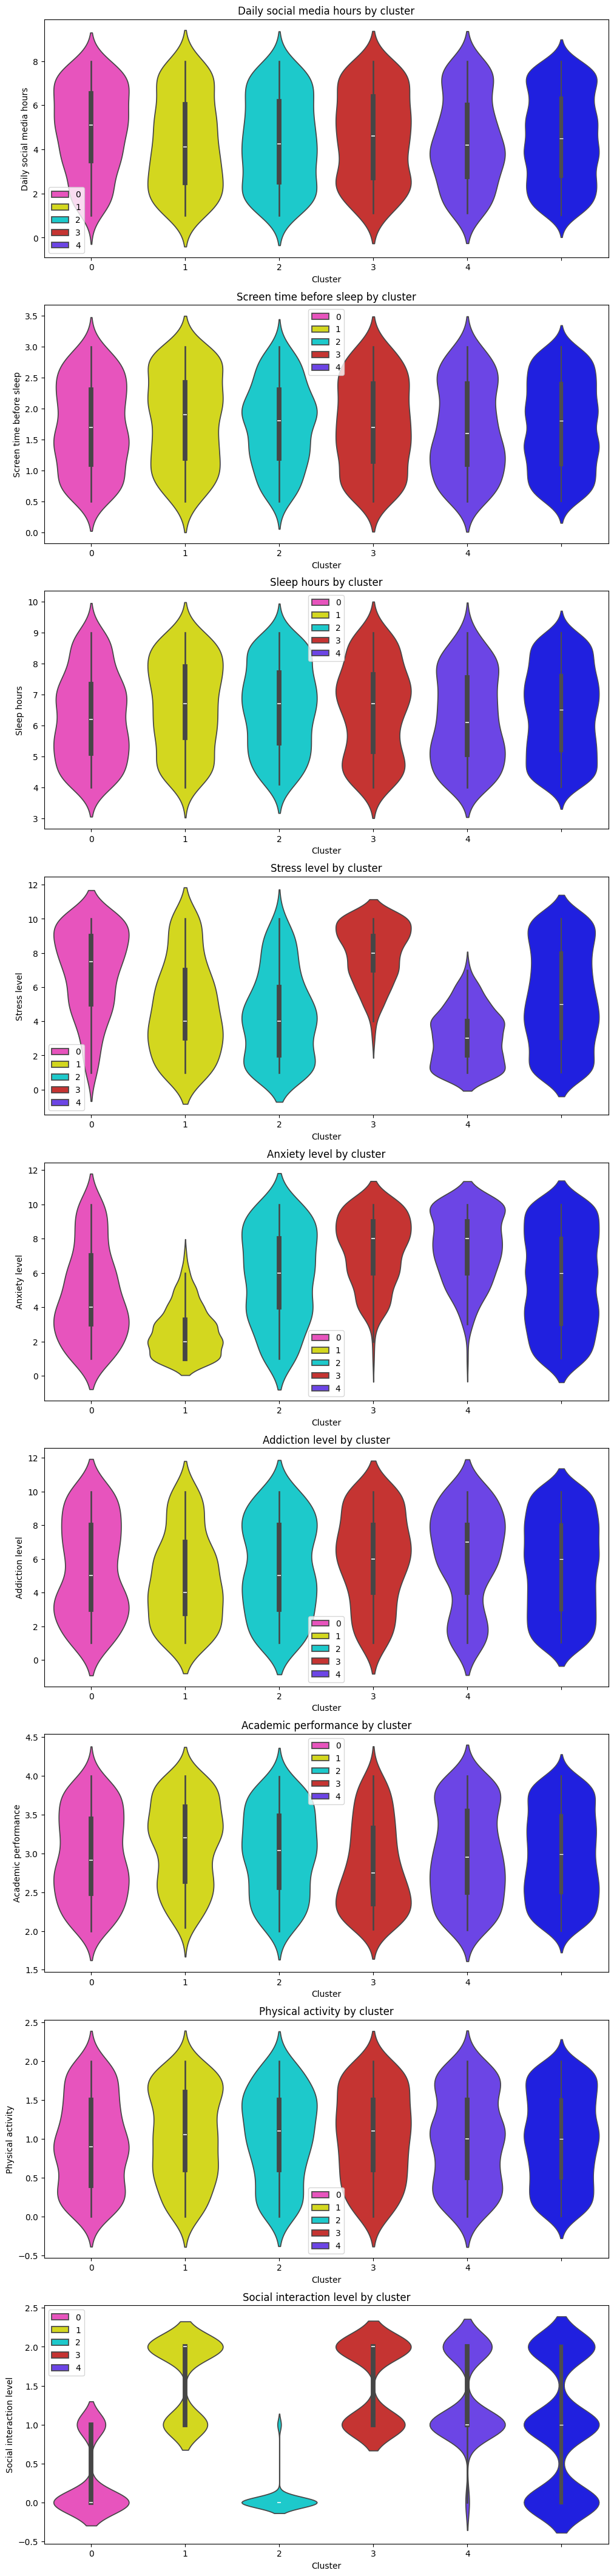

In [45]:
plt.figure(figsize=(12, 54))

plt.subplot(9, 1, 1)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["daily_social_media_hours"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["daily_social_media_hours"], color="blue", linewidth=1.0)
plt.title("Daily social media hours by cluster")
plt.ylabel("Daily social media hours")

plt.subplot(9, 1, 2)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["screen_time_before_sleep"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["screen_time_before_sleep"], color="blue", linewidth=1.0)
plt.title("Screen time before sleep by cluster")
plt.ylabel("Screen time before sleep")

plt.subplot(9, 1, 3)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["sleep_hours"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["sleep_hours"], color="blue", linewidth=1.0)
plt.title("Sleep hours by cluster")
plt.ylabel("Sleep hours")

plt.subplot(9, 1, 4)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["stress_level"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["stress_level"], color="blue", linewidth=1.0)
plt.title("Stress level by cluster")
plt.ylabel("Stress level")

plt.subplot(9, 1, 5)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["anxiety_level"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["anxiety_level"], color="blue", linewidth=1.0)
plt.title("Anxiety level by cluster")
plt.ylabel("Anxiety level")

plt.subplot(9, 1, 6)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["addiction_level"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["addiction_level"], color="blue", linewidth=1.0)
plt.title("Addiction level by cluster")
plt.ylabel("Addiction level")

plt.subplot(9, 1, 7)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["academic_performance"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["academic_performance"], color="blue", linewidth=1.0)
plt.title("Academic performance by cluster")
plt.ylabel("Academic performance")

plt.subplot(9, 1, 8)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["physical_activity"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["physical_activity"], color="blue", linewidth=1.0)
plt.title("Physical activity by cluster")
plt.ylabel("Physical activity")

plt.subplot(9, 1, 9)
sns.violinplot(x=clustered_df["Cluster"], y=clustered_df["social_interaction_level"], palette=cluster_colors, hue=clustered_df["Cluster"])
sns.violinplot(y=clustered_df["social_interaction_level"], color="blue", linewidth=1.0)
plt.title("Social interaction level by cluster")
plt.ylabel("Social interaction level")

plt.show()


# Interpretation of the KMeans results
#### Using the sns visualization and the cluster mean df.

Cluster 0
Cluster 1
Cluster 2
Cluster 3
Cluster 4

## Cluster Interpretation

The clustering analysis suggests five different student profiles based on social media use, sleep, stress, anxiety, addiction level, academic performance, physical activity, and social interaction. These profiles should be interpreted as exploratory patterns, not as definitive categories. Since the silhouette score was relatively low/moderate, there is some overlap between clusters, meaning that the groups are useful for interpretation but not perfectly separated.

### Cluster 0: Younger Stressed Low-Interaction Users

This cluster is mostly composed of younger students, with an average age of 14. They show relatively high daily social media use, lower sleep duration, the lowest physical activity level, and one of the lowest social interaction levels.

The most important point in this group is the high stress level. Even though their anxiety and addiction levels are not the highest among all clusters, they still show a potentially concerning pattern: high online time, low physical activity, low social interaction, and reduced sleep.

This profile may represent younger students who spend a considerable amount of time online but do not compensate it with enough offline social interaction, physical activity, or rest. A possible point of attention is that stress may be associated with a combination of poor sleep habits, low exercise, and limited social interaction.

### Cluster 1: Balanced Low-Risk Users

This cluster appears to be the most balanced and lowest-risk profile. Students in this group have the lowest daily social media use, the highest sleep duration, the highest academic performance, the highest physical activity, the lowest anxiety level, the lowest addiction level, and the highest social interaction level.

This suggests a healthier behavioral pattern. These students seem to have better balance between online activity, offline interaction, rest, exercise, and school performance.

A possible interpretation is that this group represents students who use social media in a more controlled way and maintain protective habits, such as sleeping more, exercising more, interacting socially, and performing better academically.

### Cluster 2: Older Isolated but Stable Users

This cluster has the highest average age, around 17.5 years. Students in this group show relatively low daily social media use, good sleep duration, good physical activity, low stress, and average academic performance. However, the most distinctive characteristic is the extremely low social interaction level.

This creates an interesting profile: these students do not show the worst mental health indicators, but they appear socially isolated compared to the other groups. Their anxiety and addiction levels are moderate, while stress is low.

A possible interpretation is that these students may have more stable routines and healthier habits, but with limited offline social interaction. This could indicate a more independent or isolated profile. The main point of attention is not necessarily excessive social media use, but the low level of social interaction.

### Cluster 3: High Distress and Academic Risk Users

This is one of the most concerning clusters. Students in this group show the highest stress level, high anxiety, high addiction level, and the lowest academic performance among all clusters. They also have relatively high daily social media use.

Unlike Cluster 0, this group does not have extremely low social interaction or physical activity. However, even with some social interaction and exercise, the levels of stress, anxiety, and addiction remain high.

This profile may represent students who are socially active and physically active, but still experience high emotional pressure and possible academic difficulties. The combination of high stress, high anxiety, high addiction, and lower academic performance makes this cluster a critical group for further investigation.

### Cluster 4: High Anxiety and High Addiction Users

This cluster is also concerning, but for a different reason. Students in this group have the highest anxiety level, the highest addiction level, and the lowest sleep duration. At the same time, they show low stress, normal academic performance, and relatively high social interaction.

This suggests that anxiety and stress may not behave in the same way in this dataset. Even though these students report low stress, their anxiety and addiction levels are very high. Their low sleep duration may also be an important risk factor.

A possible interpretation is that these students are highly connected and socially interactive, but may have difficulty regulating social media use and anxiety. Their academic performance does not appear to be strongly affected, but the combination of poor sleep, high anxiety, and high addiction should be considered a critical warning sign.

## General Conclusion

Overall, the clusters suggest that students do not follow a single pattern of social media impact. Some groups show high stress, others show high anxiety, and others show low social interaction or healthier routines. This indicates that the relationship between social media use and mental health is complex.

The most balanced group was Cluster 1, which combined lower social media use, better sleep, higher physical activity, better academic performance, lower anxiety, lower addiction, and stronger social interaction.

The most concerning groups were Cluster 3 and Cluster 4. Cluster 3 showed the strongest emotional and academic risk profile, with high stress, high anxiety, high addiction, and lower academic performance. Cluster 4 showed a different risk pattern, with high anxiety, high addiction, and poor sleep, even though stress and academic performance were not as problematic.

It is important to note that this analysis does not prove causality. The clusters only show associations between variables. Therefore, the results should be understood as exploratory profiles that can help guide further analysis, rather than as definitive explanations of student behavior.
